# Fase 1: Preprocessing & Analisis Data Eksploratif


## 1. Memuat Data & Statistik Deskriptif


In [120]:
import pandas as pd
import numpy as np

# Memuat data gizi minuman
df = pd.read_csv('data/ggl_minuman_bukan_susu.csv')

print("Data Awal:")
print(df.head())
print("\nStatistik Deskriptif:")
kolom_analisis = ['Gula (g)', 'Natrium (g)', 'Lemak Total (g)']
print(df[kolom_analisis].describe().loc[['min', 'max', 'mean']])


Data Awal:
                    Nama Produk  Lemak Total (g)  Lemak Jenuh (g)  Gula (g)  \
0                  Pocari Sweat              0.0              0.0        14   
1                       Isoplus              0.0              0.0        10   
2                   Le Minerale              0.0              0.0         0   
3  MIZONE White Isotonic Active              0.0              0.0         8   
4       You C1000 Vitamin Mango              0.0              0.0        20   

   Natrium (g)  Sajian per Kemasan  Takaran Saji          Kategori  
0        0.120                 1.5         250.0  Minuman Isotonik  
1        0.085                 2.0         175.0  Minuman Isotonik  
2        0.020                 2.0         330.0       Air Mineral  
3        0.065                 2.0         500.0  Minuman Isotonik  
4        0.055                 1.0         140.0      Minuman Soda  

Statistik Deskriptif:
       Gula (g)  Natrium (g)  Lemak Total (g)
min    0.000000     0.000000   

## 2. Visualisasi Data (Distribusi & Korelasi)


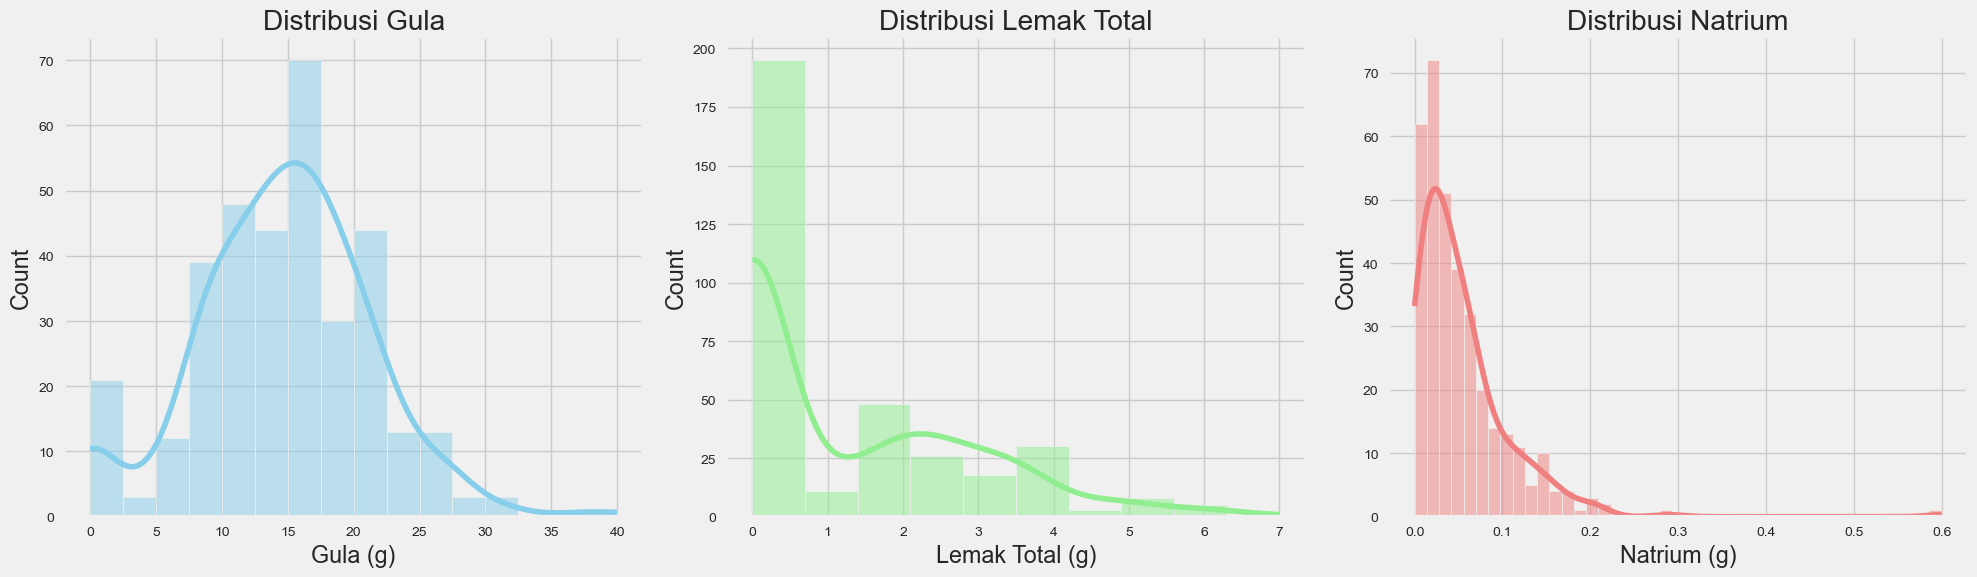

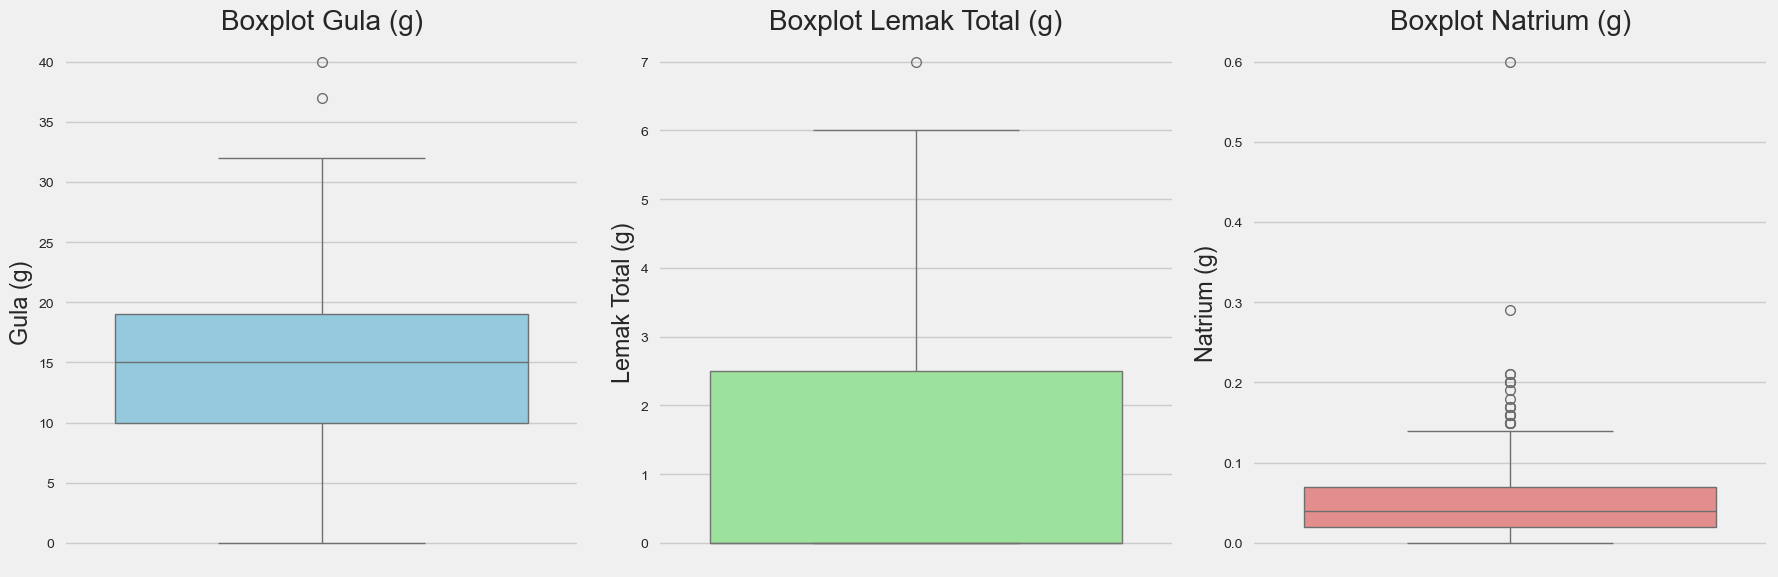

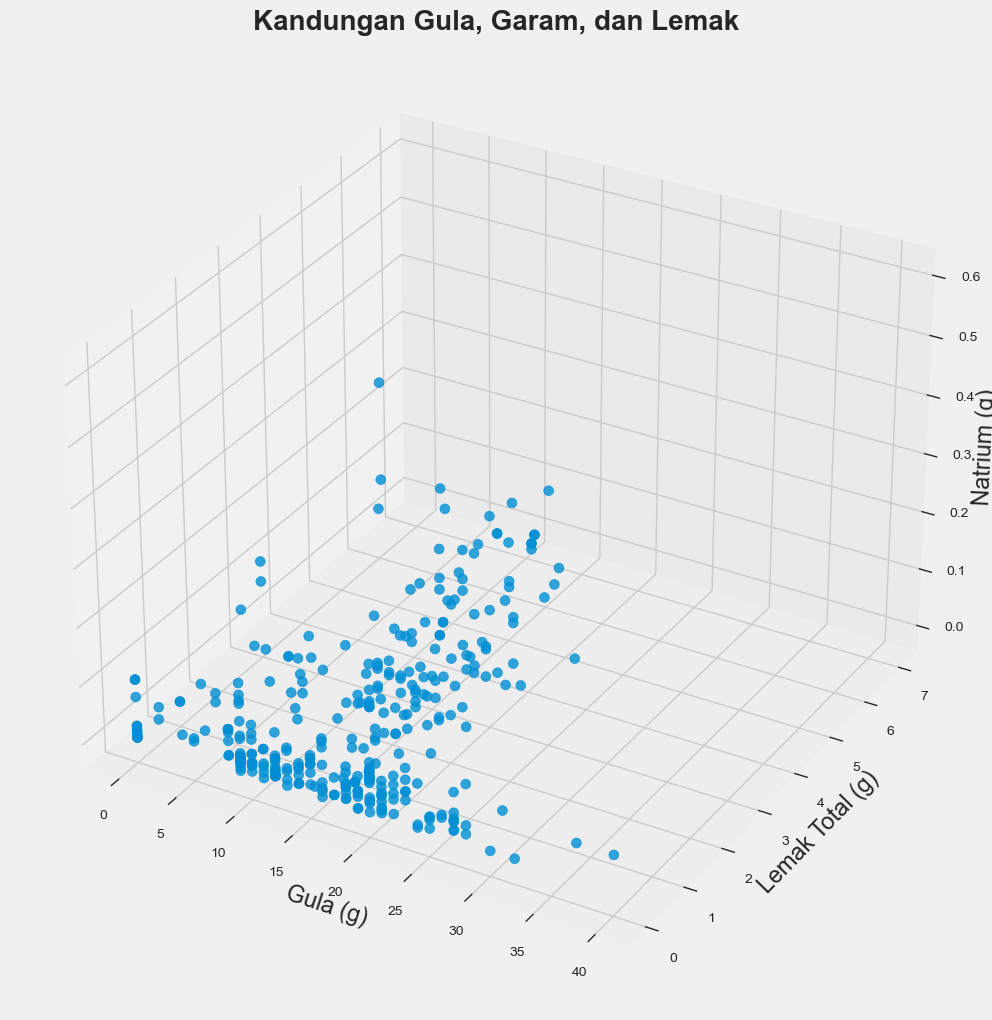

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visualisasi distribusi gizi
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.histplot(df['Gula (g)'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Gula')
sns.histplot(df['Lemak Total (g)'], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribusi Lemak Total')
sns.histplot(df['Natrium (g)'], kde=True, ax=axes[2], color='lightcoral')
axes[2].set_title('Distribusi Natrium')
plt.tight_layout()
plt.show()

# Visualisasi sebaran outlier dengan Boxplot
kolom_visualisasi = ['Gula (g)', 'Lemak Total (g)', 'Natrium (g)']
colors = ['skyblue', 'lightgreen', 'lightcoral']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, kolom in enumerate(kolom_visualisasi):
    sns.boxplot(y=df[kolom], ax=axes[i], color=colors[i])
    axes[i].set_title(f'Boxplot {kolom}')
    axes[i].set_ylabel(kolom)
plt.tight_layout()
plt.show()

# Visualisasi korelasi gizi dalam 3D Scatter Plot
fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Gula (g)'], df['Lemak Total (g)'], df['Natrium (g)'], s=50, alpha=0.8)
ax.set_xlabel('Gula (g)')
ax.set_ylabel('Lemak Total (g)')
ax.set_zlabel('Natrium (g)')
ax.set_title('Kandungan Gula, Garam, dan Lemak', fontsize=20, fontweight='bold')
plt.show()


## 3. Preprocessing (Normalisasi & Scaling)


In [122]:
from sklearn.preprocessing import StandardScaler

# Normalisasi kandungan gizi per 100 ml
df['Gula (g) per 100 ml'] = (df['Gula (g)'] / df['Takaran Saji']) * 100
df['Lemak Total (g) per 100 ml'] = (df['Lemak Total (g)'] / df['Takaran Saji']) * 100
df['Natrium (g) per 100 ml'] = (df['Natrium (g)'] / df['Takaran Saji']) * 100
df.to_csv('data/hasil_normalisasi_per_100ml.csv', index=False)

# Penskalaan fitur menggunakan StandardScaler
data_to_scale = df[['Gula (g) per 100 ml', 'Lemak Total (g) per 100 ml', 'Natrium (g) per 100 ml']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_scale)
df_scaled = pd.DataFrame(scaled_data, columns=data_to_scale.columns)

# Gabungkan data asli dan kolom hasil scaling
df_final = pd.concat([df, df_scaled.add_suffix('_scaled')], axis=1)
df_final.to_csv('data/ggl_minuman_bukan_susu_clustering.csv', index=False)

print("Preprocessing selesai. File ggl_minuman_bukan_susu_clustering.csv berhasil diekspor.")


Preprocessing selesai. File ggl_minuman_bukan_susu_clustering.csv berhasil diekspor.


# Fase 2: Clustering & Rekomendasi


## 1. Persiapan Data untuk Clustering


In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

# Load data hasil scaling
df_final = pd.read_csv('data/ggl_minuman_bukan_susu_clustering.csv')
data_scaled = df_final[['Gula (g) per 100 ml_scaled', 'Lemak Total (g) per 100 ml_scaled', 'Natrium (g) per 100 ml_scaled']].values
print(f"Data siap untuk proses clustering. Jumlah baris: {len(data_scaled)}")


Data siap untuk proses clustering. Jumlah baris: 345


## 2. K-Means Clustering


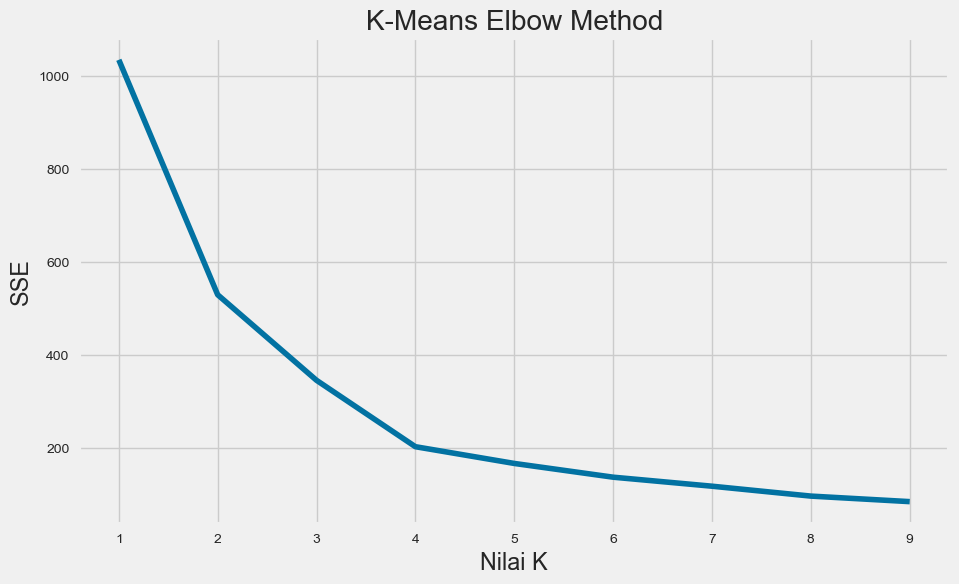

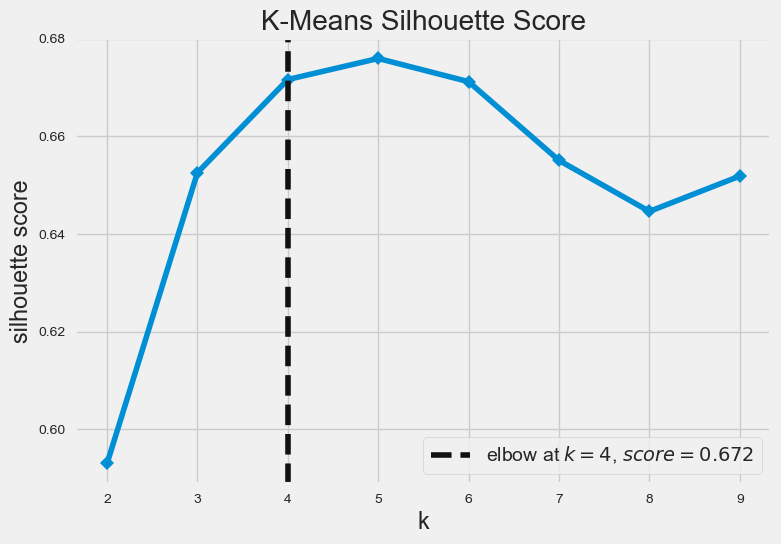

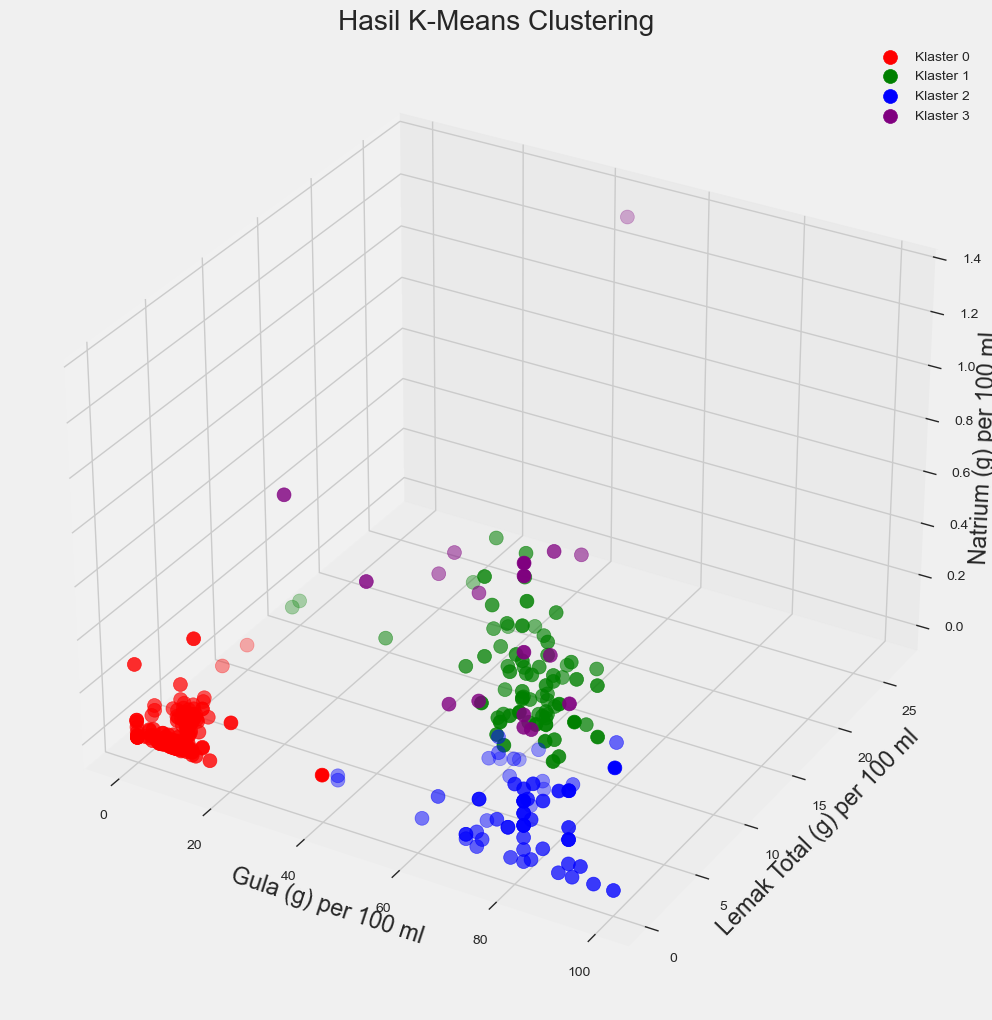

In [124]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# K-Means Elbow Method
sse = []
K_range = range(1, 10)
for k in K_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model.fit(data_scaled)
    sse.append(kmeans_model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, sse, 'bx-')
plt.xlabel('Nilai K')
plt.ylabel('SSE')
plt.title('K-Means Elbow Method')
plt.show()

# Silhouette Score
model = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=False, title='K-Means Silhouette Score')
visualizer.fit(data_scaled)
visualizer.poof()

# Eksekusi K-Means dengan k=4
optimal_k = 4
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_final['Klaster'] = kmeans_model.fit_predict(data_scaled)

# Visualisasi 3D Scatter Plot Matplotlib
fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')
cluster_labels = df_final['Klaster'].unique()
colors = ['red', 'green', 'blue', 'purple', 'orange']

for i in cluster_labels:
    ax.scatter(df_final.loc[df_final['Klaster'] == i, 'Gula (g) per 100 ml'],
               df_final.loc[df_final['Klaster'] == i, 'Lemak Total (g) per 100 ml'],
               df_final.loc[df_final['Klaster'] == i, 'Natrium (g) per 100 ml'],
               label=f'Klaster {i}', color=colors[i], s=100)
ax.set_xlabel('Gula (g) per 100 ml')
ax.set_ylabel('Lemak Total (g) per 100 ml')
ax.set_zlabel('Natrium (g) per 100 ml')
ax.set_title('Hasil K-Means Clustering')
ax.legend()
plt.show()

# Visualisasi 3D Scatter Plot Plotly
import plotly.graph_objects as go
fig = go.Figure()
for i in cluster_labels:
    cluster_data = df_final[df_final['Klaster'] == i]
    fig.add_trace(go.Scatter3d(
        x=cluster_data['Gula (g) per 100 ml'],
        y=cluster_data['Lemak Total (g) per 100 ml'],
        z=cluster_data['Natrium (g) per 100 ml'],
        mode='markers',
        marker=dict(size=8, color=colors[i], opacity=0.8),
        name=f'Klaster {i}'
    ))
fig.update_layout(
    title='Hasil K-Means Clustering',
    scene=dict(xaxis_title='Gula (g) per 100 ml', yaxis_title='Lemak Total (g) per 100 ml', zaxis_title='Natrium (g) per 100 ml'),
    width=900, height=700
)
fig.show()


## 3. Hierarchical Clustering (HC)


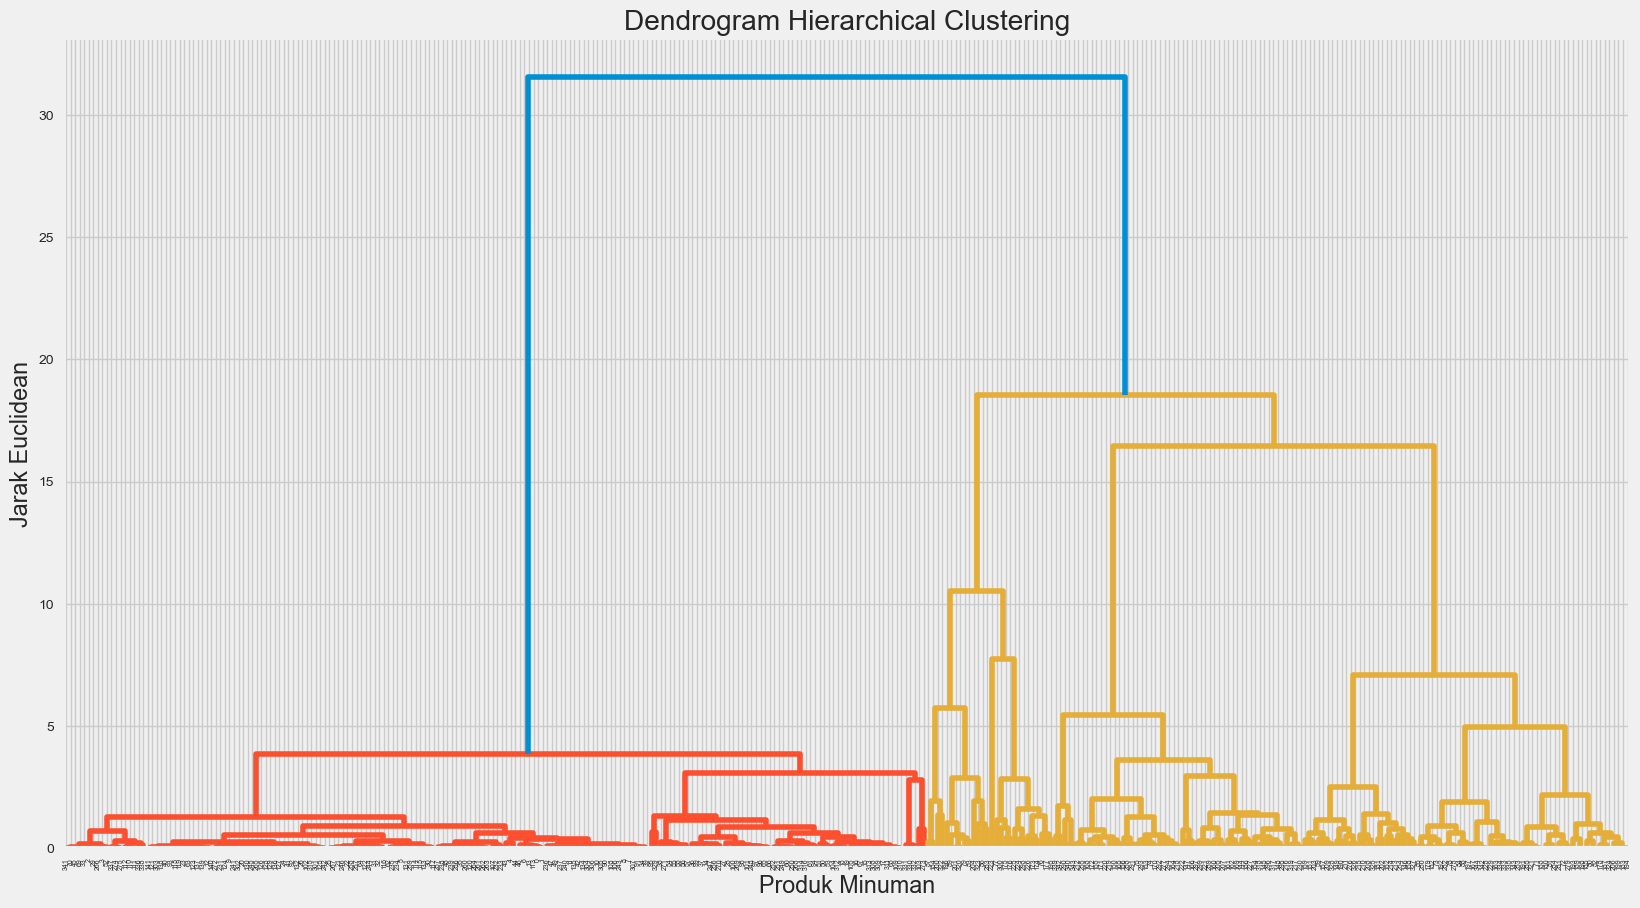

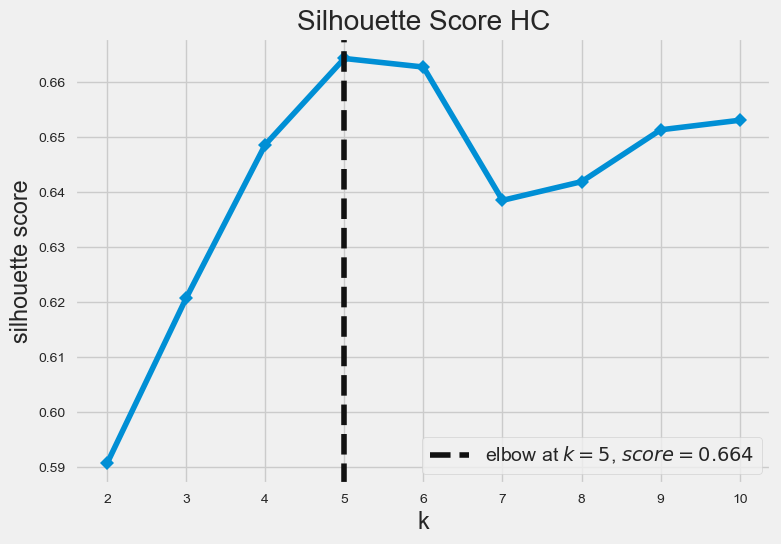

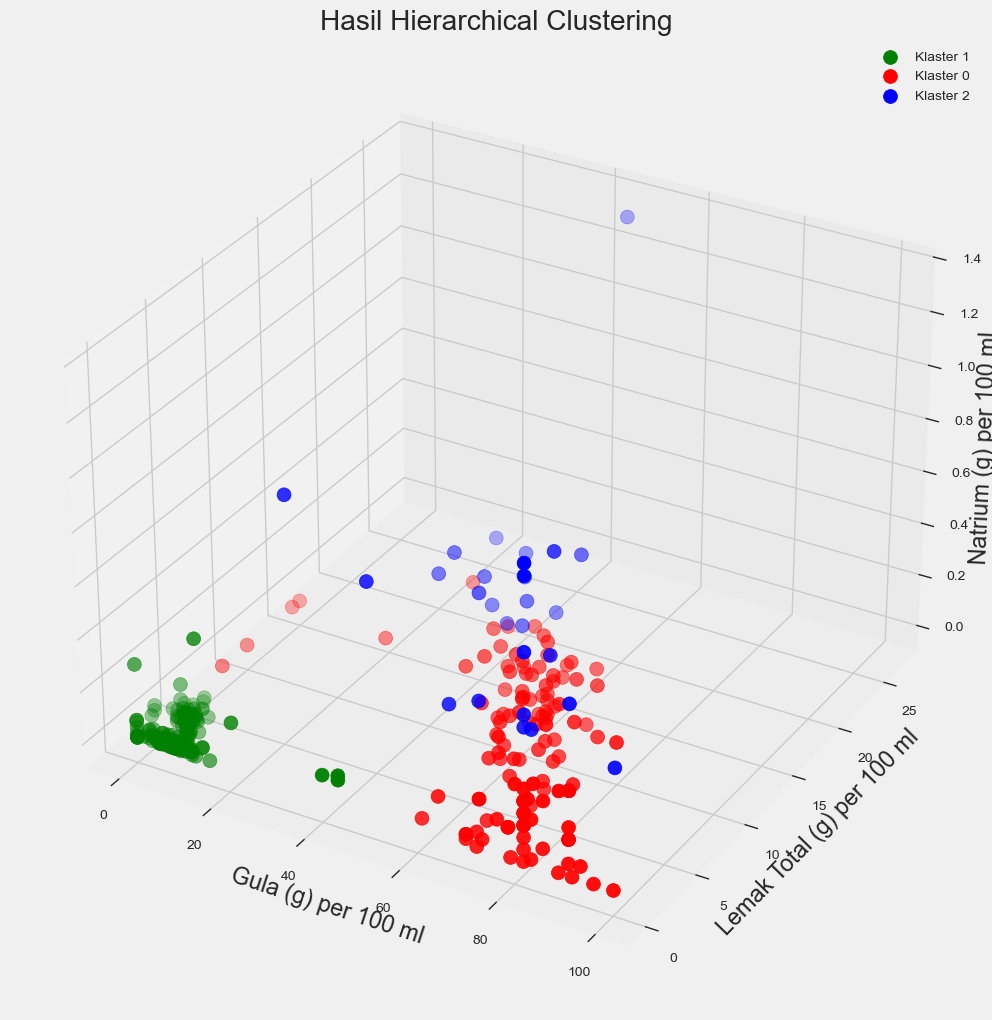

In [125]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from yellowbrick.cluster import KElbowVisualizer

# Visualisasi Dendrogram
plt.figure(figsize=(18, 10))
plt.title('Dendrogram Hierarchical Clustering')
plt.xlabel('Produk Minuman')
plt.ylabel('Jarak Euclidean')
dendrogram = sch.dendrogram(sch.linkage(data_scaled, method='ward'))
plt.show()

# Evaluasi Silhouette Score HC
hc_model = AgglomerativeClustering(metric='euclidean', linkage='ward')
visualizer = KElbowVisualizer(hc_model, k=(2, 11), metric='silhouette', timings=False, title='Silhouette Score HC')
visualizer.fit(data_scaled)
visualizer.poof()

# Eksekusi Agglomerative Clustering dengan k=3
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df_final['Klaster_HC'] = hc.fit_predict(data_scaled)

# Visualisasi 3D Scatter Plot Matplotlib
fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')
colors = ['red', 'green', 'blue']

for i in df_final['Klaster_HC'].unique():
    ax.scatter(df_final.loc[df_final['Klaster_HC'] == i, 'Gula (g) per 100 ml'],
               df_final.loc[df_final['Klaster_HC'] == i, 'Lemak Total (g) per 100 ml'],
               df_final.loc[df_final['Klaster_HC'] == i, 'Natrium (g) per 100 ml'],
               label=f'Klaster {i}', color=colors[i], s=100)
ax.set_xlabel('Gula (g) per 100 ml')
ax.set_ylabel('Lemak Total (g) per 100 ml')
ax.set_zlabel('Natrium (g) per 100 ml')
ax.set_title('Hasil Hierarchical Clustering')
ax.legend()
plt.show()

# Visualisasi 3D Scatter Plot Plotly
import plotly.graph_objects as go
fig = go.Figure()
for i in df_final['Klaster_HC'].unique():
    cluster_data = df_final[df_final['Klaster_HC'] == i]
    fig.add_trace(go.Scatter3d(
        x=cluster_data['Gula (g) per 100 ml'],
        y=cluster_data['Lemak Total (g) per 100 ml'],
        z=cluster_data['Natrium (g) per 100 ml'],
        mode='markers',
        marker=dict(size=8, color=colors[i], opacity=0.8),
        name=f'Klaster {i}'
    ))
fig.update_layout(
    title='Hasil Hierarchical Clustering',
    scene=dict(xaxis_title='Gula (g) per 100 ml', yaxis_title='Lemak Total (g) per 100 ml', zaxis_title='Natrium (g) per 100 ml'),
    width=900, height=700
)
fig.show()


## 4. DBSCAN


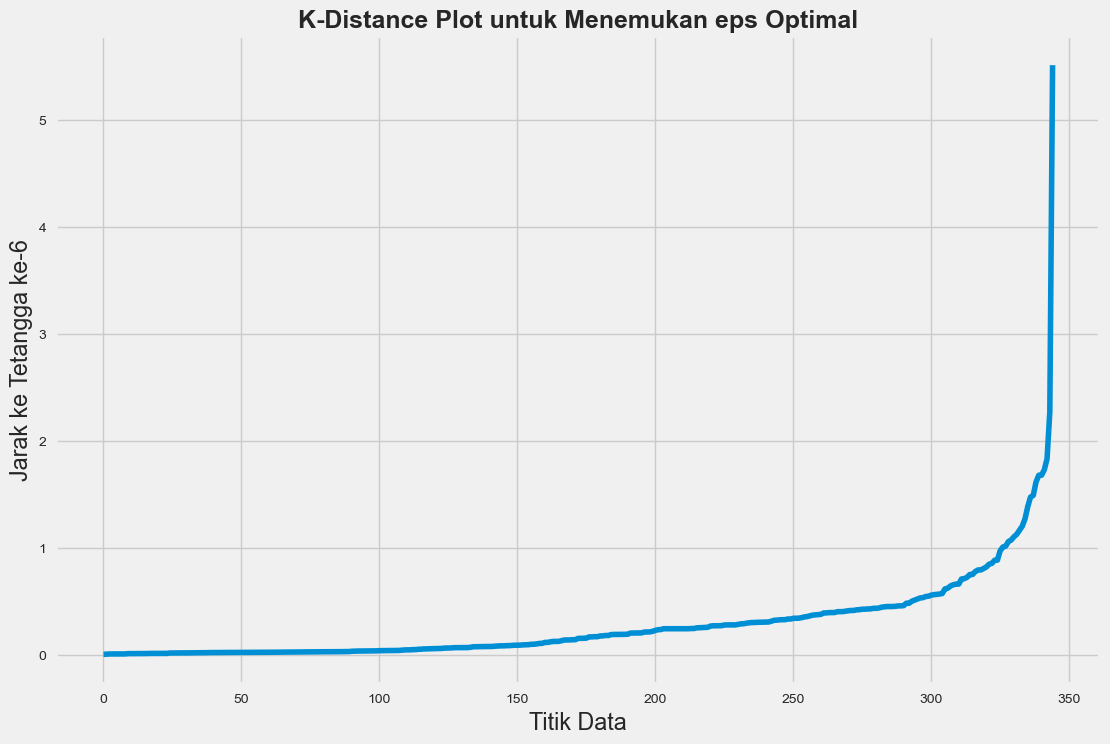

Parameter Terbaik: eps = 0.70, min_samples = 19
Jumlah klaster: 3
Jumlah noise (-1): 40


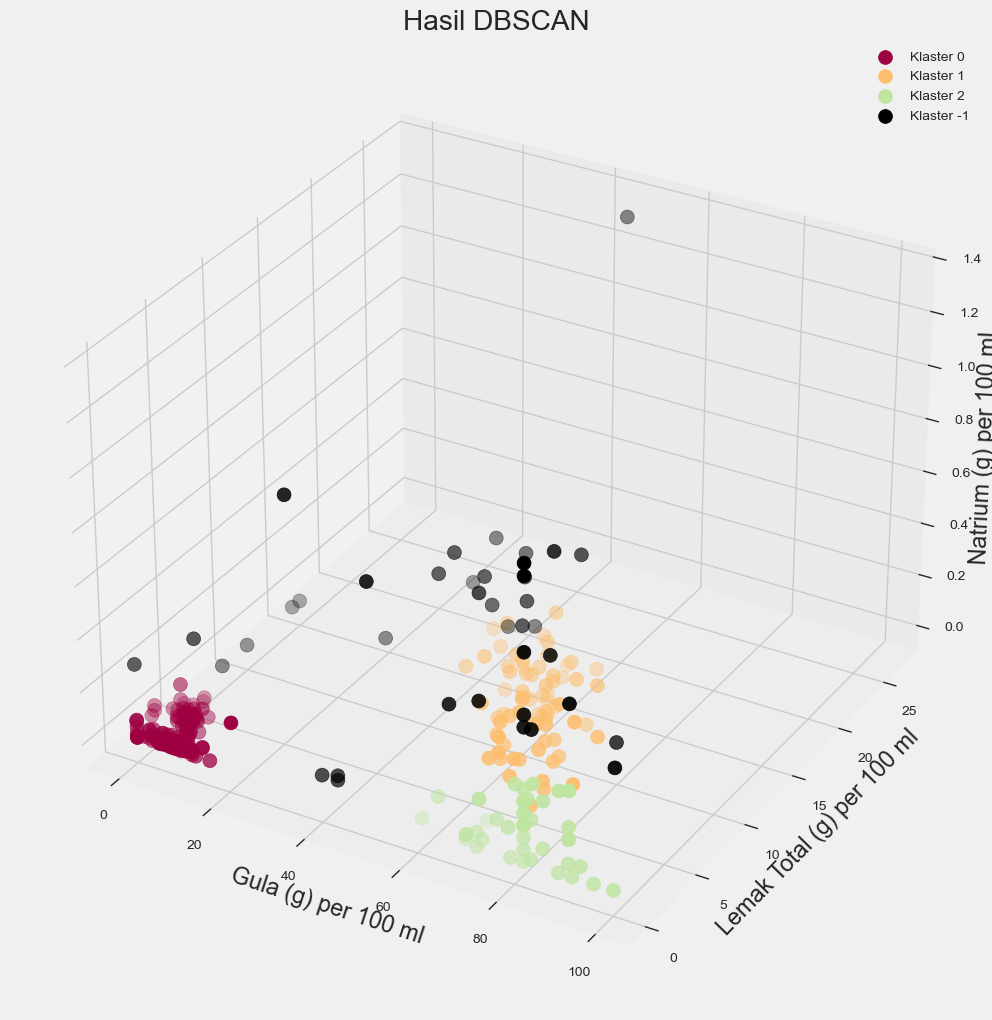

In [126]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# Jarak ke tetangga terdekat (K-Distance Plot)
min_samples_k = 6
neighbors = NearestNeighbors(n_neighbors=min_samples_k)
neighbors_fit = neighbors.fit(data_scaled)
distances, indices = neighbors_fit.kneighbors(data_scaled)
distances_to_kth_neighbor = np.sort(distances[:, min_samples_k-1], axis=0)

plt.figure(figsize=(12, 8))
plt.plot(distances_to_kth_neighbor)
plt.xlabel('Titik Data')
plt.ylabel(f'Jarak ke Tetangga ke-{min_samples_k}')
plt.title('K-Distance Plot untuk Menemukan eps Optimal', fontsize=18, fontweight='bold')
plt.grid(True)
plt.show()

# Hyperparameter Tuning DBSCAN
eps_range = np.arange(0.1, 1.5, 0.1)
min_samples_range = range(5, 20)
best_score = -1
best_params = {}

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan_model.fit_predict(data_scaled)
        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        
        if n_clusters > 1:
            score = silhouette_score(data_scaled, clusters)
            if score > best_score:
                best_score = score
                best_params = {'eps': eps, 'min_samples': min_samples}

print(f"Parameter Terbaik: eps = {best_params['eps']:.2f}, min_samples = {best_params['min_samples']}")

# Eksekusi DBSCAN dengan parameter optimal
dbscan = DBSCAN(eps=0.7, min_samples=19)
clusters = dbscan.fit_predict(data_scaled)
df_final['Klaster_DBSCAN'] = clusters

print(f"Jumlah klaster: {len(set(clusters)) - (1 if -1 in clusters else 0)}")
print(f"Jumlah noise (-1): {list(clusters).count(-1)}")

# Visualisasi 3D Scatter Plot Matplotlib
fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')
unique_labels = set(clusters)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    col = 'black' if k == -1 else tuple(c for c in col if c <= 1.0)
    df_cluster = df_final[clusters == k]
    ax.scatter(df_cluster['Gula (g) per 100 ml'],
               df_cluster['Lemak Total (g) per 100 ml'],
               df_cluster['Natrium (g) per 100 ml'],
               s=100, color=col, label=f'Klaster {k}')
ax.set_xlabel('Gula (g) per 100 ml')
ax.set_ylabel('Lemak Total (g) per 100 ml')
ax.set_zlabel('Natrium (g) per 100 ml')
ax.set_title('Hasil DBSCAN')
ax.legend()
plt.show()

# Visualisasi 3D Scatter Plot Plotly
import plotly.graph_objects as go
fig = go.Figure()
for k, col in zip(unique_labels, colors):
    col_str = 'black' if k == -1 else f'rgb({int(col[0]*255)},{int(col[1]*255)},{int(col[2]*255)})'
    label_str = 'Noise' if k == -1 else f'Klaster {k}'
    df_cluster = df_final[clusters == k]
    fig.add_trace(go.Scatter3d(
        x=df_cluster['Gula (g) per 100 ml'],
        y=df_cluster['Lemak Total (g) per 100 ml'],
        z=df_cluster['Natrium (g) per 100 ml'],
        mode='markers',
        marker=dict(size=8, color=col_str, opacity=0.8),
        name=label_str
    ))
fig.update_layout(
    title='Hasil DBSCAN',
    scene=dict(xaxis_title='Gula (g) per 100 ml', yaxis_title='Lemak Total (g) per 100 ml', zaxis_title='Natrium (g) per 100 ml'),
    width=900, height=700
)
fig.show()


## 5. Perbandingan Hasil & Ekspor Klaster Terbaik


In [127]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

scores = {}

# 1. K-Means
kmeans_labels = df_final['Klaster']
scores['K-Means'] = {
    'Silhouette Score': silhouette_score(data_scaled, kmeans_labels),
    'Davies-Bouldin Index': davies_bouldin_score(data_scaled, kmeans_labels)
}

# 2. Hierarchical
hc_labels = df_final['Klaster_HC']
scores['Hierarchical'] = {
    'Silhouette Score': silhouette_score(data_scaled, hc_labels),
    'Davies-Bouldin Index': davies_bouldin_score(data_scaled, hc_labels)
}

# 3. DBSCAN
dbscan_labels = df_final['Klaster_DBSCAN']
if len(set(dbscan_labels)) > 1 and len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0) > 1:
    dbscan_labels_filtered = dbscan_labels[dbscan_labels != -1]
    data_scaled_filtered = data_scaled[dbscan_labels != -1]
    scores['DBSCAN'] = {
        'Silhouette Score': silhouette_score(data_scaled_filtered, dbscan_labels_filtered),
        'Davies-Bouldin Index': davies_bouldin_score(data_scaled_filtered, dbscan_labels_filtered)
    }
else:
    scores['DBSCAN'] = {'Silhouette Score': None, 'Davies-Bouldin Index': None}

for method, metric_scores in scores.items():
    print(f"\nMetode: {method}")
    for metric, score in metric_scores.items():
        print(f"  - {metric}: {score:.4f}" if isinstance(score, float) else f"  - {metric}: {score}")

comparison_df = pd.DataFrame(scores).T
print("\nRingkasan Perbandingan:")
print(comparison_df)

# Simpan klaster DBSCAN (terbaik) dan ekspor dataset final
df_final['Klaster_DBSCAN'] = clusters
df_final.to_csv('data/ggl_minuman_bukan_susu_rekomendasi.csv', index=False)
print("\nFile 'data/ggl_minuman_bukan_susu_rekomendasi.csv' berhasil diekspor.")



Metode: K-Means
  - Silhouette Score: 0.6716
  - Davies-Bouldin Index: 0.6576

Metode: Hierarchical
  - Silhouette Score: 0.6207
  - Davies-Bouldin Index: 0.9595

Metode: DBSCAN
  - Silhouette Score: 0.7439
  - Davies-Bouldin Index: 0.5535

Ringkasan Perbandingan:
              Silhouette Score  Davies-Bouldin Index
K-Means               0.671629              0.657632
Hierarchical          0.620685              0.959457
DBSCAN                0.743859              0.553529

File 'data/ggl_minuman_bukan_susu_rekomendasi.csv' berhasil diekspor.


## 6. Sistem Rekomendasi Produk


In [136]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load data hasil ekspor final
df = pd.read_csv('data/ggl_minuman_bukan_susu_rekomendasi.csv')

# Fungsi Pemindaian Produk
def pindai_produk(nama_produk, df):
    produk = df[df['Nama Produk'].str.contains(nama_produk, case=False, na=False)]
    return produk.iloc[0] if not produk.empty else None

# Fungsi Sistem Rekomendasi
def rekomendasi_produk(produk_dipindai, df):
    kategori_dipindai = produk_dipindai['Kategori']
    klaster_dipindai = produk_dipindai['Klaster_DBSCAN']
    
    # Menentukan klaster target yang diizinkan (sama atau lebih sehat)
    if klaster_dipindai == 0:
        klaster_diizinkan = [0]
    elif klaster_dipindai == 1:
        klaster_diizinkan = [0, 1]
    elif klaster_dipindai == 2:
        klaster_diizinkan = [0, 1, 2]
    else:
        klaster_diizinkan = [0, 1, 2, -1]
        
    gula_dipindai = produk_dipindai['Gula (g) per 100 ml']
    lemak_dipindai = produk_dipindai['Lemak Total (g) per 100 ml']
    natrium_dipindai = produk_dipindai['Natrium (g) per 100 ml']
    
    # Filter kategori dan klaster
    df_filter = df[
        (df['Kategori'] == kategori_dipindai) & 
        (df['Klaster_DBSCAN'].isin(klaster_diizinkan)) &
        (df['Nama Produk'] != produk_dipindai['Nama Produk'])
    ]

    # Filter kandungan gizi lebih rendah atau sama
    df_filter = df_filter[
        (df_filter['Gula (g) per 100 ml'] <= gula_dipindai) &
        (df_filter['Lemak Total (g) per 100 ml'] <= lemak_dipindai) &
        (df_filter['Natrium (g) per 100 ml'] <= natrium_dipindai)
    ]
    
    if df_filter.empty:
        return pd.DataFrame()

    features = ['Gula (g) per 100 ml_scaled', 'Lemak Total (g) per 100 ml_scaled', 'Natrium (g) per 100 ml_scaled']
    produk_dipindai_vector = produk_dipindai[features].values.reshape(1, -1)
    df_filter_vectors = df_filter[features].values
    
    cosine_sim = cosine_similarity(produk_dipindai_vector, df_filter_vectors).flatten()
    df_filter = df_filter.copy()
    df_filter['Kemiripan'] = cosine_sim
    
    df_filter = df_filter.sort_values(by=['Gula (g) per 100 ml', 'Kemiripan'], ascending=[True, False])
    return df_filter.head(5)

# Pencarian Interaktif
nama_produk_pilihan = input("Masukkan nama produk: ")
produk_dipindai = pindai_produk(nama_produk_pilihan, df)

if produk_dipindai is not None:
    print(f"\nProduk yang Dipindai: {produk_dipindai['Nama Produk']}")
    print(f"Kategori: {produk_dipindai['Kategori']}")
    print(f"Kandungan Gula: {produk_dipindai['Gula (g) per 100 ml']:.2f} g per 100 ml")
    print(f"Kandungan Lemak: {produk_dipindai['Lemak Total (g) per 100 ml']:.2f} g per 100 ml")
    print(f"Kandungan Natrium: {produk_dipindai['Natrium (g) per 100 ml']:.2f} g per 100 ml")
    print("-" * 50)
    
    rekomendasi = rekomendasi_produk(produk_dipindai, df)
    if not rekomendasi.empty:
        print("Rekomendasi Produk untuk Anda:")
        print(rekomendasi[['Nama Produk', 'Kategori', 'Klaster_DBSCAN', 'Gula (g) per 100 ml', 'Lemak Total (g) per 100 ml', 'Natrium (g) per 100 ml', 'Kemiripan']])
    else:
        print(f"Produk Anda merupakan minuman yang paling sehat dalam kategori {produk_dipindai['Kategori']} dan klaster {produk_dipindai['Klaster_DBSCAN']}.")
else:
    print(f"\nProduk '{nama_produk_pilihan}' tidak ditemukan.")



Produk yang Dipindai: Golda Coffee Dolce Latte
Kategori: Minuman Kopi
Kandungan Gula: 7.50 g per 100 ml
Kandungan Lemak: 1.25 g per 100 ml
Kandungan Natrium: 0.05 g per 100 ml
--------------------------------------------------
Rekomendasi Produk untuk Anda:
                            Nama Produk      Kategori  Klaster_DBSCAN  \
62  Kopi Kenangan Original Black Coffee  Minuman Kopi               0   

    Gula (g) per 100 ml  Lemak Total (g) per 100 ml  Natrium (g) per 100 ml  \
62             5.909091                         0.0                0.027273   

    Kemiripan  
62   0.981681  


# Fase 3: Integrasi Computer Vision


## 1. Load Model & Mapping Produk


In [129]:
import os
from ultralytics import YOLO

model_path = 'best.pt'

if not os.path.exists(model_path):
    print(f"❌ ERROR: File '{model_path}' TIDAK DITEMUKAN!")
else:
    try:
        model = YOLO(model_path)
        print("✅ Model YOLO berhasil dimuat!")
        MAPPING_PRODUK = {
            0: "Golda Coffee Dolce Latte",
            1: "Nipis Madu Lime Soda",
            2: "Pocari Sweat",
            3: "Teh Pucuk Harum",
            4: "You C1000 Vitamin Orange"
        }
        print("✅ Mapping Produk siap digunakan.")
    except Exception as e:
        print(f"❌ Terjadi kesalahan saat memuat model: {e}")


✅ Model YOLO berhasil dimuat!
✅ Mapping Produk siap digunakan.


## 2. Fungsi Live Camera Scanning


In [130]:
import cv2

def start_live_scanning():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("❌ Error: Kamera tidak terdeteksi.")
        return None

    print("\n" + "="*50)
    print("   KAMERA AKTIF - MODE DETEKSI LIVE")
    print("="*50)
    print("[INFO] Jendela kamera akan muncul (Popup).")
    print("[INFO] Tekan 'S' untuk memilih/lock produk, atau 'Q' untuk keluar.")
    
    detected_product = None
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        results = model(frame, verbose=False, conf=0.7)
        annotated_frame = results[0].plot()
        
        current_view = "Mencari..."
        status_color = (0, 0, 255)
        
        if len(results[0].boxes) > 0:
            best_box = max(results[0].boxes, key=lambda x: x.conf[0])
            cls_id = int(best_box.cls[0])
            if cls_id in MAPPING_PRODUK:
                current_view = MAPPING_PRODUK[cls_id]
                status_color = (0, 255, 0)
        
        cv2.putText(annotated_frame, f"Target: {current_view}", (20, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, status_color, 2)
        cv2.putText(annotated_frame, "Tekan 'S' untuk Pilih", (20, 90), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.imshow("DG-Scan Live Detector", annotated_frame)
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord('s'):
            if current_view != "Mencari...":
                detected_product = current_view
                print(f"\n✅ BERHASIL MENGUNCI PRODUK: {detected_product}")
                break
            else:
                print("⚠️ Belum ada produk yang terdeteksi.")
        elif key == ord('q'):
            print("\n❌ Scanning dibatalkan.")
            break

    cap.release()
    cv2.destroyAllWindows()
    return detected_product


## 3. Eksekusi Pipeline Live Rekomendasi


In [131]:
# Jalankan live scanning kamera
nama_produk_pilihan = start_live_scanning()

if nama_produk_pilihan:
    print(f"\n✅ PRODUK TERPILIH DARI KAMERA: {nama_produk_pilihan}")
    produk_dipindai = pindai_produk(nama_produk_pilihan, df)

    if produk_dipindai is not None:
        print("\n" + "="*50)
        print(f"📊 HASIL ANALISIS NUTRISI: {produk_dipindai['Nama Produk']}")
        print("="*50)
        print(f"Kategori           : {produk_dipindai['Kategori']}")
        print(f"Klaster Risiko     : {produk_dipindai['Klaster_DBSCAN']}")
        print(f"Gula (per 100ml)   : {produk_dipindai['Gula (g) per 100 ml']:.2f} g")
        print(f"Lemak (per 100ml)  : {produk_dipindai['Lemak Total (g) per 100 ml']:.2f} g")
        print(f"Natrium (per 100ml): {produk_dipindai['Natrium (g) per 100 ml']:.2f} g")
        print("-" * 50)
        
        rekomendasi = rekomendasi_produk(produk_dipindai, df)
        if not rekomendasi.empty:
            print("\n💡 REKOMENDASI PRODUK LEBIH SEHAT:")
            print(rekomendasi[['Nama Produk', 'Gula (g) per 100 ml', 'Kemiripan']].to_string(index=False))
        else:
            print(f"✨ Hebat! {produk_dipindai['Nama Produk']} sudah menjadi opsi terbaik.")
    else:
        print(f"⚠️ Produk '{nama_produk_pilihan}' tidak ditemukan di database.")
else:
    print("\n❌ Scanning dibatalkan.")



   KAMERA AKTIF - MODE DETEKSI LIVE
[INFO] Jendela kamera akan muncul (Popup).
[INFO] Tekan 'S' untuk memilih/lock produk, atau 'Q' untuk keluar.

✅ BERHASIL MENGUNCI PRODUK: Teh Pucuk Harum

✅ PRODUK TERPILIH DARI KAMERA: Teh Pucuk Harum

📊 HASIL ANALISIS NUTRISI: Teh Pucuk Harum
Kategori           : Minuman Teh
Klaster Risiko     : 0
Gula (per 100ml)   : 7.50 g
Lemak (per 100ml)  : 0.00 g
Natrium (per 100ml): 0.00 g
--------------------------------------------------

💡 REKOMENDASI PRODUK LEBIH SEHAT:
               Nama Produk  Gula (g) per 100 ml  Kemiripan
Teh Pucuk Harum Less Sugar                  5.0   0.999006
